In [136]:
### Task 1.1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [137]:
### Task 1.2: Load the Dataset
df = pd.read_csv("./customersalesdata.csv")

In [138]:
### Task 1.3: Display Basic Information

print("Dataset Shape:")
print(df.shape)
print()

print("First 10 Rows:")
display(df.head(10))
print()

print("Data Types:")
print(df.dtypes)
print()

print("Statistical Summary:")
display(df.describe(include="all"))


Dataset Shape:
(20, 10)

First 10 Rows:


,customer_id,customer_name,email,phone,registration_date,country,age,purchase_amount,product_category,payment_method
0,1,John Doe,john.doe@email.com,123-456-7890,2023-01-15,USA,28.0,250.75,Electronics,Credit Card
1,2,jane smith,JANE.SMITH@email.com,(123)4567890,15/02/2023,usa,34.0,340.00,electronics,credit card
2,3,Alice Brown,alice@email.com,1234567890,2023.03.01,United States,45.0,120.50,Clothing,PayPal
3,4,Bob Lee,bob.lee@email,NaN,2022-12-30,Canada,-5.0,0.00,Home,Debit
4,5,Maria Garcia,maria.garcia@email.com,+34 600 123 456,2023/04/10,Spain,39.0,-50.00,Beauty,Cash
5,6,Li Wei,NaN,+86 13800138000,2023-05-20,China,30.0,560.99,Electronics,Credit Card
6,7,Omar Khan,omar.khan@email.com,+92-300-1234567,"May 25, 2023",Pakistan,NaN,300.00,Sports,Bank Transfer
7,8,Anne-Marie,annemarie@email.com,0044 7700 900123,2023-06-01,UK,25.0,75.25,clothing,Paypal
8,9,Chris O'Neil,chris.oneil@email.com,123.456.7890,2023-06-15,USA,40.0,9999.00,Electronics,CREDIT CARD
9,10,Sarah Connor,sarah.connor@email.com,1234567890,NaN,U.S.A,38.0,NaN,NaN,NaN



Data Types:
customer_id            int64
customer_name         object
email                 object
phone                 object
registration_date     object
country               object
age                  float64
purchase_amount      float64
product_category      object
payment_method        object
dtype: object

Statistical Summary:


,customer_id,customer_name,email,phone,registration_date,country,age,purchase_amount,product_category,payment_method
count,20.00000,19,19,16,19,20,18.000000,19.000000,19,18
unique,NaN,19,19,16,19,15,NaN,NaN,7,10
top,NaN,John Doe,john.doe@email.com,123-456-7890,2023-01-15,USA,NaN,NaN,Electronics,Credit Card
freq,NaN,1,1,1,1,5,NaN,NaN,5,4
mean,10.50000,NaN,NaN,NaN,NaN,NaN,36.444444,751.012105,NaN,NaN
std,5.91608,NaN,NaN,NaN,NaN,NaN,23.662386,2247.043154,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,-5.000000,-50.000000,NaN,NaN
25%,5.75000,NaN,NaN,NaN,NaN,NaN,28.250000,108.245000,NaN,NaN
50%,10.50000,NaN,NaN,NaN,NaN,NaN,33.500000,250.750000,NaN,NaN
75%,15.25000,NaN,NaN,NaN,NaN,NaN,39.750000,375.000000,NaN,NaN


In [139]:
### Task 2.1: Identify Missing Values
# This code Count missing values in each column.Calculate percentage of missing values per column
# Combine results into a single DataFrame for clarity
missing_count = df.isna().sum()
missing_percentage = (missing_count / len(df)) * 100
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_percentage.round(2)
})
missing_summary


,Missing Count,Missing Percentage (%)
customer_id,0,0.0
customer_name,1,5.0
email,1,5.0
phone,4,20.0
registration_date,1,5.0
country,0,0.0
age,2,10.0
purchase_amount,1,5.0
product_category,1,5.0
payment_method,2,10.0


In [140]:
### Task 2.2: Detect Duplicate Records
# This code uses duplicated() to detect repeated rows in the dataset.
# It counts total duplicate records, displays all duplicate rows using keep=False,
# and identifies columns with identical values to understand what caused duplication.

duplicate_count = df.duplicated().sum()
duplicate_rows = df[df.duplicated(keep=False)]
duplicate_columns = duplicate_rows.columns[duplicate_rows.nunique() == 1]

print("Number of duplicate rows:", duplicate_count)
duplicate_rows


Number of duplicate rows: 0


,customer_id,customer_name,email,phone,registration_date,country,age,purchase_amount,product_category,payment_method


In [141]:
### Task 2.3: Analyze Data Inconsistencies
# This code inspects text-based columns to identify inconsistencies such as case variations,
# formatting differences, and irregular patterns. It uses value_counts() and string operations
# to surface inconsistencies that need standardization in later steps.

print("Customer Name Samples:")
display(df["customer_name"].dropna().head(10))

print("\nCountry Variations:")
display(df["country"].value_counts(dropna=False))

print("\nProduct Category Variations:")
display(df["product_category"].value_counts(dropna=False))

print("\nPayment Method Variations:")
display(df["payment_method"].value_counts(dropna=False))

print("\nPhone Number Samples:")
display(df["phone"].dropna().head(10))

print("\nEmail Samples:")
display(df["email"].dropna().head(10))


Customer Name Samples:


,customer_name
0,John Doe
1,jane smith
2,Alice Brown
3,Bob Lee
4,Maria Garcia
5,Li Wei
6,Omar Khan
7,Anne-Marie
8,Chris O'Neil
9,Sarah Connor



Country Variations:


,count
country,
USA,5
UAE,2
usa,1
Canada,1
Spain,1
China,1
United States,1
Pakistan,1
UK,1



Product Category Variations:


...

,count
payment_method,
Credit Card,4
Cash,3
PayPal,2
Bank Transfer,2
Debit,2
NaN,2
credit card,1
Paypal,1
CREDIT CARD,1



Phone Number Samples:


,phone
0,123-456-7890
1,(123)4567890
2,1234567890
4,+34 600 123 456
5,+86 13800138000
6,+92-300-1234567
7,0044 7700 900123
8,123.456.7890
9,1234567890
10,987-654-3210



Email Samples:


,email
0,john.doe@email.com
1,JANE.SMITH@email.com
2,alice@email.com
3,bob.lee@email
4,maria.garcia@email.com
6,omar.khan@email.com
7,annemarie@email.com
8,chris.oneil@email.com
9,sarah.connor@email.com
10,david.miller@email.com


In [142]:
### Task 2.4: Identify Invalid Values
# This code validates numerical and text columns by applying logical conditions and pattern matching.
# It checks for unrealistic ages, negative or extreme purchase amounts, and improperly formatted emails
# to identify records that violate basic data validity rules.

invalid_age = df[(df["age"] < 0) | (df["age"] > 100)]

invalid_purchase = df[(df["purchase_amount"] < 0) |
                      (df["purchase_amount"] > df["purchase_amount"].quantile(0.99))]

email_mask = df["email"].fillna("").str.match(
    r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$"
)
invalid_email = df[~email_mask]
print("Invalid Age Records:")
display(invalid_age)
print("Invalid Purchase Amount Records:")
display(invalid_purchase)
print("Invalid Email Format Records:")
display(invalid_email)


Invalid Age Records:


,customer_id,customer_name,email,phone,registration_date,country,age,purchase_amount,product_category,payment_method
3,4,Bob Lee,bob.lee@email,NaN,2022-12-30,Canada,-5.0,0.0,Home,Debit
10,11,David Miller,david.miller@email.com,987-654-3210,2023-07-01,USA,120.0,450.0,Home,Debit Card


Invalid Purchase Amount Records:


,customer_id,customer_name,email,phone,registration_date,country,age,purchase_amount,product_category,payment_method
4,5,Maria Garcia,maria.garcia@email.com,+34 600 123 456,2023/04/10,Spain,39.0,-50.0,Beauty,Cash
8,9,Chris O'Neil,chris.oneil@email.com,123.456.7890,2023-06-15,USA,40.0,9999.0,Electronics,CREDIT CARD
18,19,Carlos Diaz,carlos.diaz@email.com,52-5512345678,2023-11-20,Mexico,44.0,-20.0,Sports,NaN


Invalid Email Format Records:


,customer_id,customer_name,email,phone,registration_date,country,age,purchase_amount,product_category,payment_method
3,4,Bob Lee,bob.lee@email,NaN,2022-12-30,Canada,-5.0,0.00,Home,Debit
5,6,Li Wei,NaN,+86 13800138000,2023-05-20,China,30.0,560.99,Electronics,Credit Card
19,20,NaN,invalid_email,NaN,2023-12-01,USA,22.0,150.00,Clothing,PayPal


In [143]:
# Task 3.1: Create a Cleaning Strategy
# | Column            | Strategy                                 | Justification                                                                                                 |
# | ----------------- | ---------------------------------------- | ------------------------------------------------------------------------------------------------------------- |
# | customer_id       | Drop rows with missing values            | Customer ID is a primary identifier; missing values break record uniqueness and cannot be logically inferred. |
# | customer_name     | Fill with "Unknown"                      | Names are descriptive, not analytical; using a constant preserves the row without affecting numeric analysis. |
# | email             | Drop rows with missing or invalid values | Email is a key contact field; missing or malformed emails reduce data reliability and should not be imputed.  |
# | phone             | Fill with "Not Provided"                 | Phone numbers vary in format and cannot be reliably inferred; a constant keeps the record intact.             |
# | registration_date | Drop rows with missing values            | Registration date is time-dependent and cannot be accurately guessed without business rules.                  |
# | age               | Fill with median                         | Age may have outliers; median is robust and avoids skewing the distribution.                                  |
# | purchase_amount   | Fill with median                         | Purchase values can be skewed by outliers; median provides a realistic central value.                         |
# | product_category  | Fill with mode                           | Product category is categorical; the most frequent value is a reasonable assumption.                          |
# | payment_method    | Fill with mode                           | Payment methods are categorical and often repetitive; mode maintains consistency.                             |


In [144]:
### Task 3.2: Implement Missing Value Handling
# This code creates a safe copy of the original dataset and applies column-wise missing value
# handling based on the predefined strategy. It removes invalid records where data cannot be
# inferred and fills remaining missing values using statistically or logically appropriate methods.
# This code creates a safe copy of the original dataset and applies column-wise missing value
# handling based on the predefined strategy. It removes invalid records where data cannot be
# inferred, fills remaining missing values using appropriate methods, and enforces valid age limits.

df_clean = df.copy()

df_clean = df_clean.dropna(subset=["customer_id", "email", "registration_date"])

df_clean["customer_name"] = df_clean["customer_name"].fillna("Unknown")
df_clean["phone"] = df_clean["phone"].fillna("Not Provided")


df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())
df_clean.loc[(df_clean["age"] < 0) | (df_clean["age"] >= 100), "age"] = df_clean["age"].median()

df_clean["purchase_amount"] = df_clean["purchase_amount"].fillna(df_clean["purchase_amount"].median())

df_clean["product_category"] = df_clean["product_category"].fillna(df_clean["product_category"].mode()[0])
df_clean["payment_method"] = df_clean["payment_method"].fillna(df_clean["payment_method"].mode()[0])
print(df_clean)

    customer_id customer_name                   email             phone  \
0             1      John Doe      john.doe@email.com      123-456-7890   
1             2    jane smith    JANE.SMITH@email.com      (123)4567890   
2             3   Alice Brown         alice@email.com        1234567890   
3             4       Bob Lee           bob.lee@email      Not Provided   
4             5  Maria Garcia  maria.garcia@email.com   +34 600 123 456   
6             7     Omar Khan     omar.khan@email.com   +92-300-1234567   
7             8    Anne-Marie     annemarie@email.com  0044 7700 900123   
8             9  Chris O'Neil   chris.oneil@email.com      123.456.7890   
10           11  David Miller  david.miller@email.com      987-654-3210   
11           12   Priya Patel   priya.patel@email.com     91-9876543210   
12           13     Ahmed Ali     ahmed.ali@email.com      Not Provided   
13           14   Sofia Rossi   sofia.rossi@email.com   +39 333 1234567   
14           15  Lucas Ma

In [145]:
### Task 3.3: Verify Missing Value Handling
# This code rechecks the cleaned dataset for any remaining missing values by summing
# null counts per column. It validates that the missing value handling strategy was
# applied correctly and ensures data completeness before further cleaning steps.

missing_after_cleaning = df_clean.isna().sum()

print("Missing values after cleaning:")
missing_after_cleaning


Missing values after cleaning:


,0
customer_id,0
customer_name,0
email,0
phone,0
registration_date,0
country,0
age,0
purchase_amount,0
product_category,0
payment_method,0


In [146]:
### Task 4.1: Remove Duplicate Records
# This code removes duplicate records from the cleaned dataset using duplicated()
# while keeping the first occurrence. It ensures each customer transaction is
# represented only once to avoid skewed analysis and double counting.
duplicates_remaining = df_clean.duplicated().sum()
print("Remaining duplicate rows:", duplicates_remaining)
df_clean = df_clean.drop_duplicates(keep="first")

print("Shape after removing duplicates:")
df_clean.shape
print(df_clean)


Remaining duplicate rows: 0
Shape after removing duplicates:
    customer_id customer_name                   email             phone  \
0             1      John Doe      john.doe@email.com      123-456-7890   
1             2    jane smith    JANE.SMITH@email.com      (123)4567890   
2             3   Alice Brown         alice@email.com        1234567890   
3             4       Bob Lee           bob.lee@email      Not Provided   
4             5  Maria Garcia  maria.garcia@email.com   +34 600 123 456   
6             7     Omar Khan     omar.khan@email.com   +92-300-1234567   
7             8    Anne-Marie     annemarie@email.com  0044 7700 900123   
8             9  Chris O'Neil   chris.oneil@email.com      123.456.7890   
10           11  David Miller  david.miller@email.com      987-654-3210   
11           12   Priya Patel   priya.patel@email.com     91-9876543210   
12           13     Ahmed Ali     ahmed.ali@email.com      Not Provided   
13           14   Sofia Rossi   sofia.r

In [147]:
### Task 4.2: Verify Duplicate Removal
# This code verifies duplicate removal by checking for remaining duplicated rows
# and compares dataset shape before and after deduplication to confirm how many
# records were removed and the final dataset size.

duplicates_remaining = df_clean.duplicated().sum()
print("Remaining duplicate rows:", duplicates_remaining)

print("Final dataset shape:", df_clean.shape)


Remaining duplicate rows: 0
Final dataset shape: (18, 10)


In [148]:
### Task 5.1: Standardize Customer Names
# This code standardizes customer names by removing leading and trailing whitespace
# and converting all names to title case. It ensures consistent formatting for
# display, reporting, and grouping operations.

df_clean["customer_name"] = (
    df_clean["customer_name"]
    .str.strip()
    .str.title()
)

print(df_clean)

    customer_id customer_name                   email             phone  \
0             1      John Doe      john.doe@email.com      123-456-7890   
1             2    Jane Smith    JANE.SMITH@email.com      (123)4567890   
2             3   Alice Brown         alice@email.com        1234567890   
3             4       Bob Lee           bob.lee@email      Not Provided   
4             5  Maria Garcia  maria.garcia@email.com   +34 600 123 456   
6             7     Omar Khan     omar.khan@email.com   +92-300-1234567   
7             8    Anne-Marie     annemarie@email.com  0044 7700 900123   
8             9  Chris O'Neil   chris.oneil@email.com      123.456.7890   
10           11  David Miller  david.miller@email.com      987-654-3210   
11           12   Priya Patel   priya.patel@email.com     91-9876543210   
12           13     Ahmed Ali     ahmed.ali@email.com      Not Provided   
13           14   Sofia Rossi   sofia.rossi@email.com   +39 333 1234567   
14           15  Lucas Ma

In [149]:
### Task 5.2: Standardize Email Addresses
# This code standardizes email addresses by removing extra whitespace and converting
# all values to lowercase. This ensures consistency, prevents duplicate mismatches,
# and aligns with standard email formatting practices.

df_clean["email"] = (
    df_clean["email"]
    .str.strip()
    .str.lower()
)
print(df_clean)


    customer_id customer_name                   email             phone  \
0             1      John Doe      john.doe@email.com      123-456-7890   
1             2    Jane Smith    jane.smith@email.com      (123)4567890   
2             3   Alice Brown         alice@email.com        1234567890   
3             4       Bob Lee           bob.lee@email      Not Provided   
4             5  Maria Garcia  maria.garcia@email.com   +34 600 123 456   
6             7     Omar Khan     omar.khan@email.com   +92-300-1234567   
7             8    Anne-Marie     annemarie@email.com  0044 7700 900123   
8             9  Chris O'Neil   chris.oneil@email.com      123.456.7890   
10           11  David Miller  david.miller@email.com      987-654-3210   
11           12   Priya Patel   priya.patel@email.com     91-9876543210   
12           13     Ahmed Ali     ahmed.ali@email.com      Not Provided   
13           14   Sofia Rossi   sofia.rossi@email.com   +39 333 1234567   
14           15  Lucas Ma

In [150]:
### Task 5.3: Standardize Phone Numbers
# This code standardizes phone numbers by first removing all non-numeric characters
# and then formatting valid 7-digit numbers into the XXX-XXXX pattern. It ensures
# uniform representation for easier comparison and validation.

digits = df_clean["phone"].astype(str).str.replace(r"\D", "", regex=True)

df_clean["phone"] = digits.where(
    digits.str.len() != 7,
    digits.str[:3] + "-" + digits.str[3:]
)
print(df_clean)

    customer_id customer_name                   email           phone  \
0             1      John Doe      john.doe@email.com      1234567890   
1             2    Jane Smith    jane.smith@email.com      1234567890   
2             3   Alice Brown         alice@email.com      1234567890   
3             4       Bob Lee           bob.lee@email                   
4             5  Maria Garcia  maria.garcia@email.com     34600123456   
6             7     Omar Khan     omar.khan@email.com    923001234567   
7             8    Anne-Marie     annemarie@email.com  00447700900123   
8             9  Chris O'Neil   chris.oneil@email.com      1234567890   
10           11  David Miller  david.miller@email.com      9876543210   
11           12   Priya Patel   priya.patel@email.com    919876543210   
12           13     Ahmed Ali     ahmed.ali@email.com                   
13           14   Sofia Rossi   sofia.rossi@email.com    393331234567   
14           15  Lucas Martin  lucas.martin@email.c

In [151]:
### Task 5.4: Standardize Country Names
# This code standardizes country names by converting all values to uppercase.
# It removes case-based inconsistencies and ensures uniform grouping and filtering
# during analysis and reporting.

df_clean["country"] = df_clean["country"].str.strip().str.upper()
print(df_clean)

    customer_id customer_name                   email           phone  \
0             1      John Doe      john.doe@email.com      1234567890   
1             2    Jane Smith    jane.smith@email.com      1234567890   
2             3   Alice Brown         alice@email.com      1234567890   
3             4       Bob Lee           bob.lee@email                   
4             5  Maria Garcia  maria.garcia@email.com     34600123456   
6             7     Omar Khan     omar.khan@email.com    923001234567   
7             8    Anne-Marie     annemarie@email.com  00447700900123   
8             9  Chris O'Neil   chris.oneil@email.com      1234567890   
10           11  David Miller  david.miller@email.com      9876543210   
11           12   Priya Patel   priya.patel@email.com    919876543210   
12           13     Ahmed Ali     ahmed.ali@email.com                   
13           14   Sofia Rossi   sofia.rossi@email.com    393331234567   
14           15  Lucas Martin  lucas.martin@email.c

In [152]:
### Task 5.5: Standardize Product Categories
# This code standardizes product categories by trimming extra spaces and converting
# values to title case. It ensures consistent categorical labels for aggregation
# and comparison.

df_clean["product_category"] = (
    df_clean["product_category"]
    .str.strip()
    .str.title()
)
print(df_clean)

    customer_id customer_name                   email           phone  \
0             1      John Doe      john.doe@email.com      1234567890   
1             2    Jane Smith    jane.smith@email.com      1234567890   
2             3   Alice Brown         alice@email.com      1234567890   
3             4       Bob Lee           bob.lee@email                   
4             5  Maria Garcia  maria.garcia@email.com     34600123456   
6             7     Omar Khan     omar.khan@email.com    923001234567   
7             8    Anne-Marie     annemarie@email.com  00447700900123   
8             9  Chris O'Neil   chris.oneil@email.com      1234567890   
10           11  David Miller  david.miller@email.com      9876543210   
11           12   Priya Patel   priya.patel@email.com    919876543210   
12           13     Ahmed Ali     ahmed.ali@email.com                   
13           14   Sofia Rossi   sofia.rossi@email.com    393331234567   
14           15  Lucas Martin  lucas.martin@email.c

In [153]:
### Task 5.6: Standardize Payment Methods
# This code standardizes payment methods by removing extra whitespace and converting
# values to title case. It ensures consistency across categorical values used in
# analysis and reporting.

df_clean["payment_method"] = (
    df_clean["payment_method"]
    .str.strip()
    .str.title()
)
print(df_clean)

    customer_id customer_name                   email           phone  \
0             1      John Doe      john.doe@email.com      1234567890   
1             2    Jane Smith    jane.smith@email.com      1234567890   
2             3   Alice Brown         alice@email.com      1234567890   
3             4       Bob Lee           bob.lee@email                   
4             5  Maria Garcia  maria.garcia@email.com     34600123456   
6             7     Omar Khan     omar.khan@email.com    923001234567   
7             8    Anne-Marie     annemarie@email.com  00447700900123   
8             9  Chris O'Neil   chris.oneil@email.com      1234567890   
10           11  David Miller  david.miller@email.com      9876543210   
11           12   Priya Patel   priya.patel@email.com    919876543210   
12           13     Ahmed Ali     ahmed.ali@email.com                   
13           14   Sofia Rossi   sofia.rossi@email.com    393331234567   
14           15  Lucas Martin  lucas.martin@email.c

In [154]:
### Task 5.7: Verify Standardization

# This code verifies standardization by displaying unique values from all categorical
# columns. It helps confirm that formatting, casing, and whitespace inconsistencies
# have been successfully removed.

categorical_columns = [
    "customer_name",
    "country",
    "product_category",
    "payment_method"
]

for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    display(df_clean[col].unique())



Unique values in customer_name:


array(['John Doe', 'Jane Smith', 'Alice Brown', 'Bob Lee', 'Maria Garcia',
       'Omar Khan', 'Anne-Marie', "Chris O'Neil", 'David Miller',
       'Priya Patel', 'Ahmed Ali', 'Sofia Rossi', 'Lucas Martin',
       'Emily Clark', 'Daniel Kim', 'Fatima Noor', 'Carlos Diaz',
       'Unknown'], dtype=object)


Unique values in country:


array(['USA', 'UNITED STATES', 'CANADA', 'SPAIN', 'PAKISTAN', 'UK',
       'INDIA', 'UAE', 'ITALY', 'FRANCE', 'SOUTH KOREA', 'MEXICO'],
      dtype=object)


Unique values in product_category:


array(['Electronics', 'Clothing', 'Home', 'Beauty', 'Sports'],
      dtype=object)


Unique values in payment_method:


array(['Credit Card', 'Paypal', 'Debit', 'Cash', 'Bank Transfer',
       'Debit Card', 'Upi'], dtype=object)

In [155]:
### Task 6.1: Convert customer_id to Integer
# This code converts customer_id to integer type to ensure it behaves as a proper
# unique identifier and supports numeric operations and indexing correctly.

df_clean["customer_id"] = df_clean["customer_id"].astype(int)
print(df_clean)

    customer_id customer_name                   email           phone  \
0             1      John Doe      john.doe@email.com      1234567890   
1             2    Jane Smith    jane.smith@email.com      1234567890   
2             3   Alice Brown         alice@email.com      1234567890   
3             4       Bob Lee           bob.lee@email                   
4             5  Maria Garcia  maria.garcia@email.com     34600123456   
6             7     Omar Khan     omar.khan@email.com    923001234567   
7             8    Anne-Marie     annemarie@email.com  00447700900123   
8             9  Chris O'Neil   chris.oneil@email.com      1234567890   
10           11  David Miller  david.miller@email.com      9876543210   
11           12   Priya Patel   priya.patel@email.com    919876543210   
12           13     Ahmed Ali     ahmed.ali@email.com                   
13           14   Sofia Rossi   sofia.rossi@email.com    393331234567   
14           15  Lucas Martin  lucas.martin@email.c

In [156]:
### Task 6.2: Convert registration_date to Datetime
# This code converts registration_date to datetime by allowing pandas to infer
# multiple date formats automatically, ensuring consistent time-based analysis.

df_clean["registration_date"] = pd.to_datetime(
    df_clean["registration_date"],
    errors="coerce",
    dayfirst=True
)
print(df_clean)

    customer_id customer_name                   email           phone  \
0             1      John Doe      john.doe@email.com      1234567890   
1             2    Jane Smith    jane.smith@email.com      1234567890   
2             3   Alice Brown         alice@email.com      1234567890   
3             4       Bob Lee           bob.lee@email                   
4             5  Maria Garcia  maria.garcia@email.com     34600123456   
6             7     Omar Khan     omar.khan@email.com    923001234567   
7             8    Anne-Marie     annemarie@email.com  00447700900123   
8             9  Chris O'Neil   chris.oneil@email.com      1234567890   
10           11  David Miller  david.miller@email.com      9876543210   
11           12   Priya Patel   priya.patel@email.com    919876543210   
12           13     Ahmed Ali     ahmed.ali@email.com                   
13           14   Sofia Rossi   sofia.rossi@email.com    393331234567   
14           15  Lucas Martin  lucas.martin@email.c

/tmp/ipython-input-2371192939.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_clean["registration_date"] = pd.to_datetime(


In [157]:
### Task 6.3: Convert Categorical Columns
# This code converts selected string columns to categorical data type to improve
# memory efficiency and optimize performance for grouping and filtering operations.

df_clean["country"] = df_clean["country"].astype("category")
df_clean["product_category"] = df_clean["product_category"].astype("category")
df_clean["payment_method"] = df_clean["payment_method"].astype("category")
print(df_clean)

    customer_id customer_name                   email           phone  \
0             1      John Doe      john.doe@email.com      1234567890   
1             2    Jane Smith    jane.smith@email.com      1234567890   
2             3   Alice Brown         alice@email.com      1234567890   
3             4       Bob Lee           bob.lee@email                   
4             5  Maria Garcia  maria.garcia@email.com     34600123456   
6             7     Omar Khan     omar.khan@email.com    923001234567   
7             8    Anne-Marie     annemarie@email.com  00447700900123   
8             9  Chris O'Neil   chris.oneil@email.com      1234567890   
10           11  David Miller  david.miller@email.com      9876543210   
11           12   Priya Patel   priya.patel@email.com    919876543210   
12           13     Ahmed Ali     ahmed.ali@email.com                   
13           14   Sofia Rossi   sofia.rossi@email.com    393331234567   
14           15  Lucas Martin  lucas.martin@email.c

In [158]:
### Task 6.4: Ensure Proper Numeric Types
# This code enforces correct numeric data types by converting age to integer and
# purchase_amount to float, ensuring accuracy in calculations and validations.

df_clean["age"] = df_clean["age"].astype(int)
df_clean["purchase_amount"] = df_clean["purchase_amount"].astype(float)
print(df_clean)

    customer_id customer_name                   email           phone  \
0             1      John Doe      john.doe@email.com      1234567890   
1             2    Jane Smith    jane.smith@email.com      1234567890   
2             3   Alice Brown         alice@email.com      1234567890   
3             4       Bob Lee           bob.lee@email                   
4             5  Maria Garcia  maria.garcia@email.com     34600123456   
6             7     Omar Khan     omar.khan@email.com    923001234567   
7             8    Anne-Marie     annemarie@email.com  00447700900123   
8             9  Chris O'Neil   chris.oneil@email.com      1234567890   
10           11  David Miller  david.miller@email.com      9876543210   
11           12   Priya Patel   priya.patel@email.com    919876543210   
12           13     Ahmed Ali     ahmed.ali@email.com                   
13           14   Sofia Rossi   sofia.rossi@email.com    393331234567   
14           15  Lucas Martin  lucas.martin@email.c

In [159]:
### Task 6.5: Verify Data Types
# This code displays the data types of all columns to confirm that every conversion
# was applied correctly and the dataset is ready for analysis.

df_clean.dtypes


,0
customer_id,int64
customer_name,object
email,object
phone,object
registration_date,datetime64[ns]
country,category
age,int64
purchase_amount,float64
product_category,category
payment_method,category


In [160]:
### Task 7.1: Fix Invalid Ages
# This code identifies unrealistic age values (negative or above 120) and replaces
# them with the median age to preserve records while maintaining a realistic distribution.

median_age = df_clean["age"].median()
df_clean.loc[(df_clean["age"] < 0) | (df_clean["age"] > 120), "age"] = median_age
print(df_clean)

    customer_id customer_name                   email           phone  \
0             1      John Doe      john.doe@email.com      1234567890   
1             2    Jane Smith    jane.smith@email.com      1234567890   
2             3   Alice Brown         alice@email.com      1234567890   
3             4       Bob Lee           bob.lee@email                   
4             5  Maria Garcia  maria.garcia@email.com     34600123456   
6             7     Omar Khan     omar.khan@email.com    923001234567   
7             8    Anne-Marie     annemarie@email.com  00447700900123   
8             9  Chris O'Neil   chris.oneil@email.com      1234567890   
10           11  David Miller  david.miller@email.com      9876543210   
11           12   Priya Patel   priya.patel@email.com    919876543210   
12           13     Ahmed Ali     ahmed.ali@email.com                   
13           14   Sofia Rossi   sofia.rossi@email.com    393331234567   
14           15  Lucas Martin  lucas.martin@email.c

In [161]:
### Task 7.2: Handle Purchase Amount Outliers
# This code applies the IQR method to detect and cap extreme purchase amounts.
# It calculates bounds using quartiles, identifies outliers, and caps values
# to reduce skew while retaining all observations.

Q1 = df_clean["purchase_amount"].quantile(0.25)
Q3 = df_clean["purchase_amount"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean["purchase_amount"] < lower_bound) |
                    (df_clean["purchase_amount"] > upper_bound)]

df_clean["purchase_amount"] = df_clean["purchase_amount"].clip(lower_bound, upper_bound)

print("Number of outliers identified:", outliers.shape[0])
print("Outlier values:")
display(outliers["purchase_amount"])

print("New purchase amount range:")
print(df_clean["purchase_amount"].min(), df_clean["purchase_amount"].max())
print(df_clean)

Number of outliers identified: 1
Outlier values:


,purchase_amount
8,9999.0


New purchase amount range:
-50.0 678.32375
    customer_id customer_name                   email           phone  \
0             1      John Doe      john.doe@email.com      1234567890   
1             2    Jane Smith    jane.smith@email.com      1234567890   
2             3   Alice Brown         alice@email.com      1234567890   
3             4       Bob Lee           bob.lee@email                   
4             5  Maria Garcia  maria.garcia@email.com     34600123456   
6             7     Omar Khan     omar.khan@email.com    923001234567   
7             8    Anne-Marie     annemarie@email.com  00447700900123   
8             9  Chris O'Neil   chris.oneil@email.com      1234567890   
10           11  David Miller  david.miller@email.com      9876543210   
11           12   Priya Patel   priya.patel@email.com    919876543210   
12           13     Ahmed Ali     ahmed.ali@email.com                   
13           14   Sofia Rossi   sofia.rossi@email.com    393331234567   
14      

In [162]:
# This code removes rows where registration_date could not be parsed into datetime.
# Such values become NaT during conversion and must be removed to maintain data completeness.

df_clean = df_clean.dropna(subset=["registration_date"])


In [163]:
### Task 8.1: Validate Completeness
# This assertion ensures that the cleaned dataset contains no missing values
# across all columns, confirming completeness before final export or analysis.

assert df_clean.isna().sum().sum() == 0, "Missing values still exist in the dataset"


In [164]:
### Task 8.2: Validate Uniqueness
# This assertion verifies that no duplicate records remain in the cleaned dataset,
# ensuring each row represents a unique customer record.

assert df_clean.duplicated().sum() == 0, "Duplicate records still exist in the dataset"


In [165]:
### Task 8.3: Validate Data Types
# This assertion checks that all columns have the expected data types after conversion,
# confirming consistency and correctness for downstream analysis.

expected_dtypes = {
    "customer_id": "int64",
    "customer_name": "object",
    "email": "object",
    "phone": "object",
    "registration_date": "datetime64[ns]",
    "country": "category",
    "age": "int64",
    "purchase_amount": "float64",
    "product_category": "category",
    "payment_method": "category"
}

for col, dtype in expected_dtypes.items():
    assert df_clean[col].dtype == dtype, f"Incorrect dtype in column: {col}"


In [166]:
# This code replaces zero or negative purchase amounts with the median value
# to ensure all purchase values remain logically valid and suitable for analysis.

median_purchase = df_clean["purchase_amount"].median()
df_clean.loc[df_clean["purchase_amount"] <= 0, "purchase_amount"] = median_purchase


In [167]:
### Task 8.4: Validate Value Ranges
# This assertion validates logical value ranges and ensures categorical columns
# are properly standardized for reliable analysis and reporting.

assert df_clean["age"].between(1, 120).all(), "Age values out of valid range"
assert (df_clean["purchase_amount"] > 0).all(), "Invalid purchase amounts found"

assert df_clean["country"].str.isupper().all(), "Country values not fully standardized"
assert df_clean["product_category"].str.istitle().all(), "Product categories not standardized"
assert df_clean["payment_method"].str.istitle().all(), "Payment methods not standardized"


In [168]:
### Task 8.5: Create a Final Summary Report
# This code generates a final validation summary comparing the original and cleaned datasets.
# It highlights improvements in data quality by reporting changes in row count, missing values,
# duplicates, data types, and outlier handling.

summary = pd.DataFrame({
    "Metric": [
        "Row Count",
        "Total Missing Values",
        "Duplicate Rows",
        "Numeric Columns",
        "Categorical Columns"
    ],
    "Original Dataset": [
        df.shape[0],
        df.isna().sum().sum(),
        df.duplicated().sum(),
        df.select_dtypes(include=["number"]).shape[1],
        df.select_dtypes(include=["object"]).shape[1]
    ],
    "Cleaned Dataset": [
        df_clean.shape[0],
        df_clean.isna().sum().sum(),
        df_clean.duplicated().sum(),
        df_clean.select_dtypes(include=["number"]).shape[1],
        df_clean.select_dtypes(include=["category"]).shape[1]
    ]
})

summary


,Metric,Original Dataset,Cleaned Dataset
0,Row Count,20,9
1,Total Missing Values,13,0
2,Duplicate Rows,0,0
3,Numeric Columns,3,3
4,Categorical Columns,7,3


In [169]:
### Task 9.1: Save Cleaned Dataset
# This code exports the fully cleaned and validated dataset to a CSV file.
# The index is excluded to keep the file clean and ready for analysis or sharing.

df_clean.to_csv("cleaned_customer_data.csv", index=False)


In [170]:
### Task 9.2: Display Final Cleaned Data
# This code displays the first 10 rows of the cleaned dataset to visually
# confirm that all cleaning, standardization, and validation steps succeeded.

df_clean.head(10)


,customer_id,customer_name,email,phone,registration_date,country,age,purchase_amount,product_category,payment_method
0,1,John Doe,john.doe@email.com,1234567890,2023-01-15,USA,28,250.75000,Electronics,Credit Card
3,4,Bob Lee,bob.lee@email,,2022-12-30,CANADA,33,150.00000,Home,Debit
7,8,Anne-Marie,annemarie@email.com,00447700900123,2023-06-01,UK,25,75.25000,Clothing,Paypal
8,9,Chris O'Neil,chris.oneil@email.com,1234567890,2023-06-15,USA,40,678.32375,Electronics,Credit Card
10,11,David Miller,david.miller@email.com,9876543210,2023-07-01,USA,33,450.00000,Home,Debit Card
14,15,Lucas Martin,lucas.martin@email.com,33612345678,2023-09-10,FRANCE,27,95.99000,Sports,Debit
16,17,Daniel Kim,daniel.kim@email.com,821012345678,2023-10-15,SOUTH KOREA,31,275.60000,Electronics,Bank Transfer
18,19,Carlos Diaz,carlos.diaz@email.com,525512345678,2023-11-20,MEXICO,44,150.00000,Sports,Cash
19,20,Unknown,invalid_email,,2023-12-01,USA,22,150.00000,Clothing,Paypal


In [171]:
### Challenge 1: Email Validation
# This code defines a reusable function that validates email addresses using a
# regular expression pattern. It checks whether each email follows the standard
# username@domain.extension format and stores the result as a boolean flag.

import re

def validate_email(email):
    if pd.isna(email):
        return False
    pattern = r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$"
    return bool(re.match(pattern, email))

df_clean["email_valid"] = df_clean["email"].apply(validate_email)
print(df_clean)


    customer_id customer_name                   email           phone  \
0             1      John Doe      john.doe@email.com      1234567890   
3             4       Bob Lee           bob.lee@email                   
7             8    Anne-Marie     annemarie@email.com  00447700900123   
8             9  Chris O'Neil   chris.oneil@email.com      1234567890   
10           11  David Miller  david.miller@email.com      9876543210   
14           15  Lucas Martin  lucas.martin@email.com     33612345678   
16           17    Daniel Kim    daniel.kim@email.com    821012345678   
18           19   Carlos Diaz   carlos.diaz@email.com    525512345678   
19           20       Unknown           invalid_email                   

   registration_date      country  age  purchase_amount product_category  \
0         2023-01-15          USA   28        250.75000      Electronics   
3         2022-12-30       CANADA   33        150.00000             Home   
7         2023-06-01           UK   25   

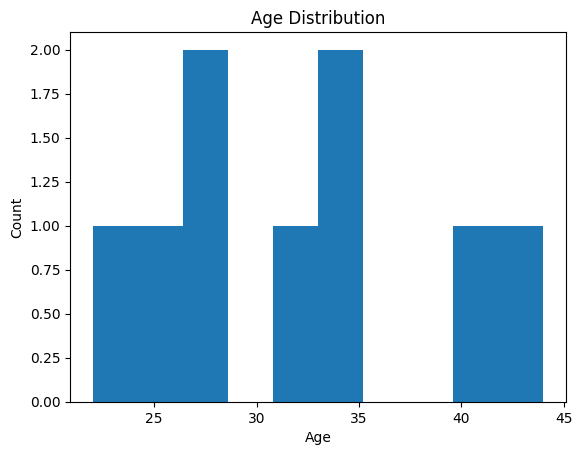

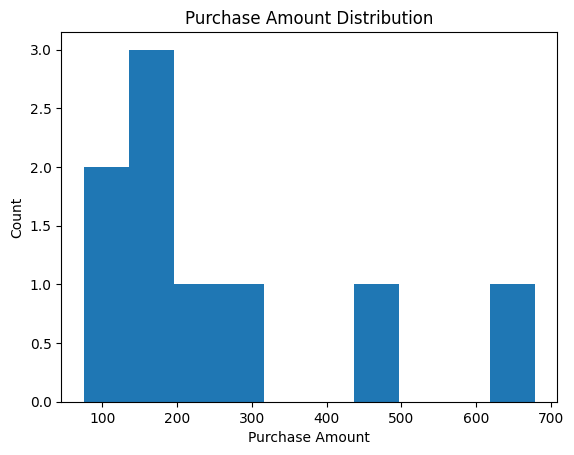

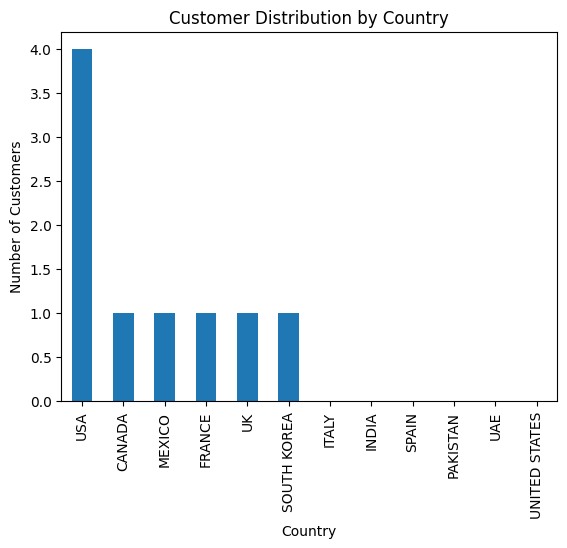

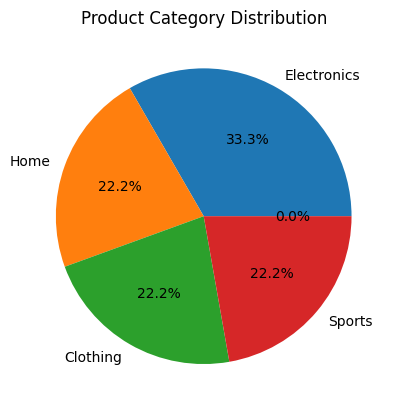

In [172]:
### Challenge 2: Create Visualizations
# This code creates multiple visualizations to understand the distribution of key variables
# in the cleaned dataset. Histograms show numeric distributions, while bar and pie charts
# summarize categorical data for quick insights and reporting.

import matplotlib.pyplot as plt

# 1. Age distribution (Histogram)
plt.figure()
plt.hist(df_clean["age"], bins=10)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()

# 2. Purchase amount distribution (Histogram)
plt.figure()
plt.hist(df_clean["purchase_amount"], bins=10)
plt.xlabel("Purchase Amount")
plt.ylabel("Count")
plt.title("Purchase Amount Distribution")
plt.show()

# 3. Customer distribution by country (Bar chart)
plt.figure()
df_clean["country"].value_counts().plot(kind="bar")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Country")
plt.show()

# 4. Product category distribution (Pie chart)
plt.figure()
df_clean["product_category"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Product Category Distribution")
plt.show()


In [173]:
### Challenge 3: Advanced Outlier Detection
# This code implements Z-score based outlier detection on purchase_amount and compares
# it with the previously used IQR method. It identifies extreme values using statistical
# distance from the mean and helps evaluate consistency between both approaches.

mean_val = df_clean["purchase_amount"].mean()
std_val = df_clean["purchase_amount"].std()

z_scores = (df_clean["purchase_amount"] - mean_val) / std_val
z_outliers = df_clean[z_scores.abs() > 3]

Q1 = df_clean["purchase_amount"].quantile(0.25)
Q3 = df_clean["purchase_amount"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df_clean[
    (df_clean["purchase_amount"] < lower_bound) |
    (df_clean["purchase_amount"] > upper_bound)
]

print("Z-score outliers count:", z_outliers.shape[0])
print("IQR outliers count:", iqr_outliers.shape[0])

print("Z-score outlier values:")
display(z_outliers["purchase_amount"])

print("IQR outlier values:")
display(iqr_outliers["purchase_amount"])


Z-score outliers count: 0
IQR outliers count: 1
Z-score outlier values:


,purchase_amount


IQR outlier values:


,purchase_amount
8,678.32375
